<a href="https://colab.research.google.com/github/vaibhav051422-collab/machine-learning/blob/main/graduateadmission.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Install the Kaggle API client

In [1]:
!pip install kaggle

## 2. Set up Kaggle API Credentials

To download datasets, you need to authenticate with Kaggle. Follow these steps to get your `kaggle.json` file:

1. Go to [Kaggle](https://www.kaggle.com/).
2. Click on your profile picture in the top right corner and select "My Account".
3. Scroll down to the "API" section and click "Create New API Token". This will download a `kaggle.json` file to your computer.

Now, upload this `kaggle.json` file to your Colab environment. You can do this by running the following cell, which will prompt you to upload the file.

In [2]:
from google.colab import files

files.upload()

Saving graduate.zip to graduate.zip


{'graduate.zip': b'PK\x03\x04-\x00\x00\x00\x08\x00v\x03<O\x0c..\xff\xff\xff\xff\xff\xff\xff\xff\xff\x15\x00\x14\x00Admission_Predict.csv\x01\x00\x10\x00g2\x00\x00\x00\x00\x00\x00\x83\x10\x00\x00\x00\x00\x00\x00mZ\xdd\xaa&\xb7\x11\xbc_\xd8w\xd8\x07\x18>F\xff\xd2\xa51\x8eoLl\xec\xe4\x01\x16g\x13/$6\xd8&\x90\xb7\x8f\xaa\xbb\xba[slN\x0ca5\xa3OjUWW\xb5\xe6\x87O\xbf~\xfe\xf8\xef\x0f\x7f\xfd\xe5u}\xfd\xfdW\x1f~\xf8\xf1\x97_?]\x7f\xfb\xf6\xab\xbf|\xc3\xff\xff\xf7\x9f?\xff\xf7\xd3\xaf\xbf}\xfe\xfd\x7f\x1f\xbe\xff\xf8\xfb\xe7\x9f\xffu\xfd\xf0\xedw\xd77\xdf~\xff\xe1\xfa\xf2\xeb\xef\xbe\xb8\xbe\xff\xf4\xdb\xa7\x8f\xbf\xfe\xf8\xd3\xf5\xe5O\x1f\x7f\xfe\xf1\xd3\x87_\xfe\xf9\xe1\x8b\x7f\xfc\xe7\xf3\xef\x1f\xde\xbfKW)\xe3Ji^\xf5\xaa\xaf&\xff\xadWoW\xba\xee\xd7\xca\xef\xdf\xe5\xab\xe4z\xa5{\xe0\x01\x19\x9e\xaf9dx\xf4\xf7\xef\xcaUR\xdf\xc3\xf5*\xf8\xc3\xb0\x8e\xedW\xf7\xbf\xe5\xbc\xe7\xbe9\x92\xe5\xe5\xae/\xcf\xf7\xef\xda~\x17S\x97+\xef\xbf\xb2\xc7\xf2\x1e\xd9c\xbd\xbd\x7f\xd7\xf7\xc2\xee\xfdr\xbbtQe/\xa

After uploading, move the `kaggle.json` file to the correct directory and set permissions:

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


## 3. Find and Download a Dataset

You can find datasets on Kaggle. For example, let's use the "Titanic - Machine Learning from Disaster" dataset.

The dataset's API command is usually found on the dataset's page under "Data > API". It looks something like `kaggle datasets download -d [owner]/[dataset-name]`.

For Titanic, it's `kaggle datasets download -d titanic` (since it's an old dataset owned by Kaggle directly).

If you want to use a different dataset, replace `titanic` with the appropriate dataset identifier.

In [6]:
# Unzip the uploaded graduate.zip file
!unzip graduate.zip

Archive:  graduate.zip
  inflating: Admission_Predict.csv   
  inflating: Admission_Predict_Ver1.1.csv  


In [7]:
import pandas as pd

# Load the 'Admission_Predict.csv' file into a DataFrame
df = pd.read_csv('Admission_Predict.csv')

# Display the first 5 rows to verify the data loading
display(df.head())

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         400 non-null    int64  
 1   GRE Score          400 non-null    int64  
 2   TOEFL Score        400 non-null    int64  
 3   University Rating  400 non-null    int64  
 4   SOP                400 non-null    float64
 5   LOR                400 non-null    float64
 6   CGPA               400 non-null    float64
 7   Research           400 non-null    int64  
 8   Chance of Admit    400 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 28.3 KB


In [9]:
df.shape

(400, 9)

In [10]:
df.drop(columns=['Serial No.'],inplace=True)

In [12]:
df.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65


In [13]:
X=df.iloc[:,0:-1]
Y=df.iloc[:,-1]

In [14]:
Y

,Chance of Admit
0,0.92
1,0.76
2,0.72
3,0.80
4,0.65
...,...
395,0.82
396,0.84
397,0.91
398,0.67


In [17]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [18]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [22]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense



In [39]:
model=Sequential()
model.add(Dense(7,activation='relu',input_dim=7))
model.add(Dense(7,activation='relu',input_dim=7))
model.add(Dense(1,activation='linear'))



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [40]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 7)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 120 (480.00 B)

 Trainable params: 120 (480.00 B)

 Non-trainable params: 0 (0.00 B)

In [41]:
model.compile(optimizer='adam',loss='mean_squared_error')

In [47]:
history = model.fit(X_train_scaled,Y_train,epochs=10,validation_split=0.2)

Epoch 1/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0167 - val_loss: 0.0172
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0159 - val_loss: 0.0180
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0156 - val_loss: 0.0164
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0143 - val_loss: 0.0146
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0133 - val_loss: 0.0136
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0128 - val_loss: 0.0129
Epoch 7/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0122 - val_loss: 0.0123
Epoch 8/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0117 - val_loss: 0.0119
Epoch 9/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0112 - val_loss: 0.0115
Epoch 10/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0108 - val_loss: 0.0111


In [48]:
y_pred=model.predict(X_test_scaled)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


In [49]:
from sklearn.metrics import r2_score
r2_score(Y_test,y_pred)

0.6353317125358486

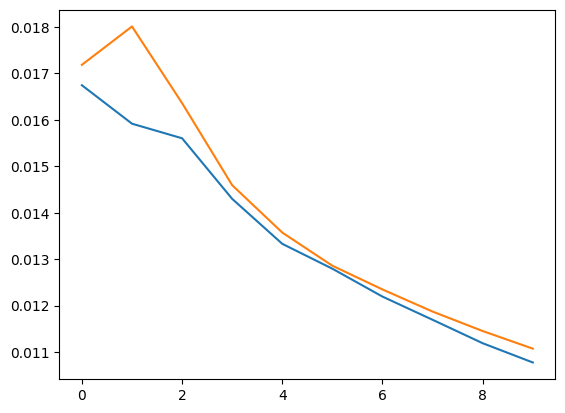

In [51]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
